# Baseline FAYAM — Cluster 6 (5 fonctions)

Entraînement **dédié au Cluster 6  ** (fonctions 138, 139, 140, 143, 144 — profil populaire ~122 000 inv/min).
Un seul modèle, une seule population homogène — reproductible avec les hyperparamètres FAYAM.

| Champ | Valeur |
|-------|--------|
| **Run** | `baseline-cluster6` |
| **Phase** | Phase 1 — Reproduction baseline (cluster unique) |
| **Seed** | 998 |
| **Epochs** | 51 |
| **Dataset** | `cluster_6.csv` — 5 séries × 20 160 pas |

> Avant de lancer : Runtime → Change runtime type → **T4 GPU**

## 1 — Setup

In [1]:
import subprocess
gpu = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else 'Pas de GPU — vérifier le runtime.')

Tue May  5 17:22:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
!pip install -q transformers datasets "gluonts[torch]" accelerate evaluate scipy scikit-learn tqdm openpyxl ujson

## 2 — Imports, seed et configuration

In [3]:
import random, os, json
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from functools import lru_cache, partial
from typing import Optional, Iterable
from tqdm.notebook import tqdm

SEED = 998
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'PyTorch    : {torch.__version__}')
print(f'CUDA dispo : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')

PyTorch    : 2.10.0+cu128
CUDA dispo : True
GPU        : Tesla T4


In [4]:
# ── Hyperparamètres FAYAM (source unique) ────────────────────────────────────
FREQ               = '1T'
PREDICTION_LENGTH  = 120
CONTEXT_LENGTH     = PREDICTION_LENGTH * 2
ENCODER_LAYERS     = 4
DECODER_LAYERS     = 4
D_MODEL            = 32
EMBEDDING_DIM      = [2]

BATCH_SIZE_TRAIN   = 256
BATCH_SIZE_TEST    = 64
NUM_BATCHES_EPOCH  = 100
NUM_EPOCHS         = 51
LR                 = 6e-4
BETAS              = (0.9, 0.95)
WEIGHT_DECAY       = 1e-1
GRAD_CLIP_NORM     = 1.0
CHECKPOINT_EVERY   = 10

CLUSTER_ID = 6
RUN_NAME   = f'baseline-cluster{CLUSTER_ID}'
print(f'Config OK — Cluster {CLUSTER_ID} | RUN_NAME={RUN_NAME}')

Config OK — Cluster 6 | RUN_NAME=baseline-cluster6


## 3 — Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = f'/content/drive/MyDrive/m2-xai-faas/experiments/{RUN_NAME}'
for subdir in ['checkpoints', 'results', 'attentions']:
    os.makedirs(f'{DRIVE_BASE}/{subdir}', exist_ok=True)
print(f'Dossier run : {DRIVE_BASE}')

Mounted at /content/drive
Dossier run : /content/drive/MyDrive/m2-xai-faas/experiments/baseline-cluster6


## 4 — Chargement du dataset (Cluster 6 uniquement)

In [6]:
from pathlib import Path
from datasets import Dataset

try:
    from google.colab import drive as _drive  # noqa: F401
    DATA_DIR = Path('/content/drive/MyDrive/Recherche/Datasets')
except ImportError:
    DATA_DIR = Path('../../memoire/06-datasets/raw').resolve()

START_DATE = '2021-01-01 00:00:00'

df = pd.read_csv(DATA_DIR / f'cluster_{CLUSTER_ID}.csv', index_col='Function')
all_series = []
for func_id, row in df.iterrows():
    all_series.append({
        'function_id': int(func_id),
        'cluster':     CLUSTER_ID,
        'target_full': row.values.astype(np.float32),
    })

print(f'Cluster {CLUSTER_ID} — {len(all_series)} fonctions :')
for s in all_series:
    print(f"  function_id={s['function_id']}  "
          f"longueur={len(s['target_full'])}  "
          f"moy={s['target_full'].mean():.0f}  "
          f"max={s['target_full'].max():.0f}  "
          f"min={s['target_full'].min():.0f}")

train_rows, test_rows = [], []
for ts_idx, s in enumerate(all_series):
    base = {
        'start':           START_DATE,
        'feat_static_cat': [ts_idx],
        'cluster':         s['cluster'],
        'function_id':     s['function_id'],
    }
    train_rows.append({**base, 'target': s['target_full'][:-PREDICTION_LENGTH].tolist()})
    test_rows.append({**base,  'target': s['target_full'].tolist()})

train_dataset = Dataset.from_list(train_rows)
test_dataset  = Dataset.from_list(test_rows)
print(f'\nSéries train : {len(train_dataset)} | Séries test : {len(test_dataset)}')

Cluster 6 — 5 fonctions :
  function_id=138  longueur=20160  moy=2  max=232  min=0
  function_id=139  longueur=20160  moy=2  max=232  min=0
  function_id=140  longueur=20160  moy=2  max=232  min=0
  function_id=143  longueur=20160  moy=2  max=232  min=0
  function_id=144  longueur=20160  moy=3  max=280  min=0

Séries train : 5 | Séries test : 5


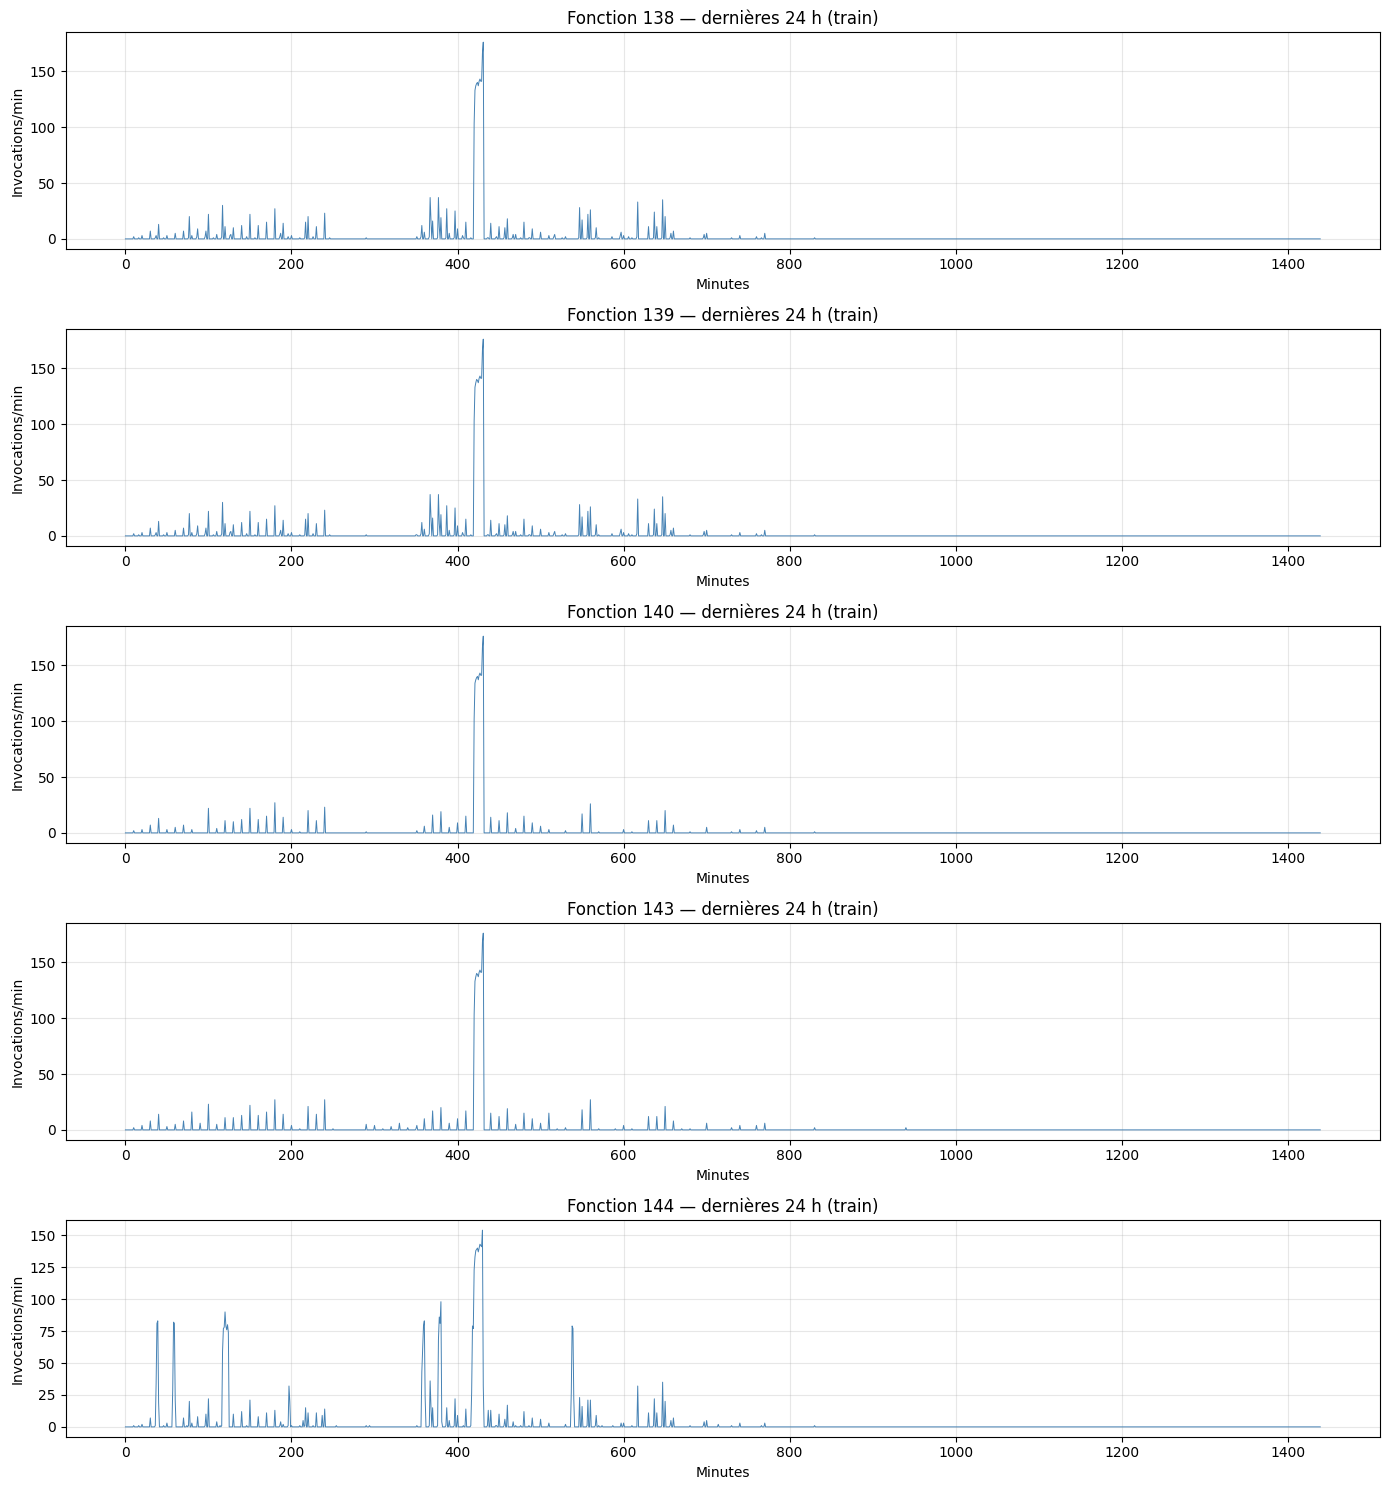

In [7]:
# Vue d'ensemble : 24 heures de chaque fonction (1440 pas)
fig, axes = plt.subplots(len(all_series), 1, figsize=(14, 3 * len(all_series)), squeeze=False)
for i, (s, ax) in enumerate(zip(all_series, axes.flatten())):
    ax.plot(s['target_full'][-1440:], linewidth=0.7, color='steelblue')
    ax.set_title(f"Fonction {s['function_id']} — dernières 24 h (train)")
    ax.set_xlabel('Minutes')
    ax.set_ylabel('Invocations/min')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — Pipeline GluonTS

In [8]:
from gluonts.time_feature import get_lags_for_frequency, time_features_from_frequency_str
from gluonts.dataset.field_names import FieldName
from gluonts.transform import (
    AddAgeFeature, AddObservedValuesIndicator, AddTimeFeatures,
    AsNumpyArray, Chain, ExpectedNumInstanceSampler, InstanceSplitter,
    RemoveFields, TestSplitSampler, Transformation,
    ValidationSplitSampler, VstackFeatures, RenameFields,
)
from gluonts.transform.sampler import InstanceSampler
from gluonts.itertools import Cyclic, Cached
from gluonts.dataset.loader import as_stacked_batches
from transformers import PretrainedConfig

lags_sequence = get_lags_for_frequency(FREQ)
time_features  = time_features_from_frequency_str(FREQ)

@lru_cache(10_000)
def convert_to_pandas_period(date, freq):
    return pd.Period(date, freq)

def transform_start_field(batch, freq):
    batch['start'] = [convert_to_pandas_period(d, freq) for d in batch['start']]
    return batch

train_dataset.set_transform(partial(transform_start_field, freq=FREQ))
test_dataset.set_transform(partial(transform_start_field, freq=FREQ))
print(f'Lags : {len(lags_sequence)} | Time features : {len(time_features)}')

Lags : 22 | Time features : 5


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/lag.py:104: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


In [9]:
def create_transformation(freq, config):
    remove_field_names = []
    if config.num_static_real_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_REAL)
    if config.num_dynamic_real_features == 0:
        remove_field_names.append(FieldName.FEAT_DYNAMIC_REAL)
    if config.num_static_categorical_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_CAT)
    return Chain(
        [RemoveFields(field_names=remove_field_names)]
        + ([AsNumpyArray(field=FieldName.FEAT_STATIC_CAT, expected_ndim=1, dtype=int)]
           if config.num_static_categorical_features > 0 else [])
        + [AsNumpyArray(field=FieldName.TARGET, expected_ndim=1),
           AddObservedValuesIndicator(target_field=FieldName.TARGET,
                                     output_field=FieldName.OBSERVED_VALUES),
           AddTimeFeatures(start_field=FieldName.START, target_field=FieldName.TARGET,
                           output_field=FieldName.FEAT_TIME,
                           time_features=time_features_from_frequency_str(freq),
                           pred_length=config.prediction_length),
           AddAgeFeature(target_field=FieldName.TARGET, output_field=FieldName.FEAT_AGE,
                         pred_length=config.prediction_length, log_scale=True),
           VstackFeatures(output_field=FieldName.FEAT_TIME,
                          input_fields=[FieldName.FEAT_TIME, FieldName.FEAT_AGE]),
           RenameFields(mapping={
               FieldName.FEAT_STATIC_CAT: 'static_categorical_features',
               FieldName.FEAT_TIME:       'time_features',
               FieldName.TARGET:          'values',
               FieldName.OBSERVED_VALUES: 'observed_mask',
           })]
    )

def create_instance_splitter(config, mode, train_sampler=None, validation_sampler=None):
    assert mode in ['train', 'validation', 'test']
    sampler = {
        'train':      train_sampler or ExpectedNumInstanceSampler(
                          num_instances=1.0, min_future=config.prediction_length),
        'validation': validation_sampler or ValidationSplitSampler(
                          min_future=config.prediction_length),
        'test':       TestSplitSampler(),
    }[mode]
    return InstanceSplitter(
        target_field='values', is_pad_field=FieldName.IS_PAD,
        start_field=FieldName.START, forecast_start_field=FieldName.FORECAST_START,
        instance_sampler=sampler,
        past_length=config.context_length + max(config.lags_sequence),
        future_length=config.prediction_length,
        time_series_fields=['time_features', 'observed_mask'],
    )

def _pred_fields(config):
    f = ['past_time_features', 'past_values', 'past_observed_mask', 'future_time_features']
    if config.num_static_categorical_features > 0: f.append('static_categorical_features')
    return f

def create_train_dataloader(config, freq, data, batch_size, num_batches_per_epoch, **kw):
    fields = _pred_fields(config) + ['future_values', 'future_observed_mask']
    tr = create_transformation(freq, config)
    td = Cached(tr.apply(data, is_train=True))
    sp = create_instance_splitter(config, 'train')
    return as_stacked_batches(sp.apply(Cyclic(td).stream()),
                              batch_size=batch_size, field_names=fields,
                              output_type=torch.tensor,
                              num_batches_per_epoch=num_batches_per_epoch)

def create_backtest_dataloader(config, freq, data, batch_size, **kw):
    tr = create_transformation(freq, config)
    sp = create_instance_splitter(config, 'validation')
    return as_stacked_batches(sp.apply(tr.apply(data), is_train=True),
                              batch_size=batch_size, output_type=torch.tensor,
                              field_names=_pred_fields(config))

def create_attention_dataloader(config, freq, data, batch_size=1):
    fields = _pred_fields(config) + ['future_values', 'future_observed_mask']
    tr = create_transformation(freq, config)
    sp = create_instance_splitter(config, 'validation')
    return as_stacked_batches(sp.apply(tr.apply(data), is_train=True),
                              batch_size=batch_size, output_type=torch.tensor,
                              field_names=fields)

print('Pipeline GluonTS défini.')

Pipeline GluonTS défini.


## 6 — Modèle

In [10]:
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction

config = TimeSeriesTransformerConfig(
    prediction_length=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    lags_sequence=lags_sequence,
    num_time_features=len(time_features) + 1,
    num_static_categorical_features=1,
    cardinality=[len(train_dataset)],   # 3 séries
    embedding_dimension=EMBEDDING_DIM,
    encoder_layers=ENCODER_LAYERS,
    decoder_layers=DECODER_LAYERS,
    d_model=D_MODEL,
)

model  = TimeSeriesTransformerForPrediction(config)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Paramètres  : {n_params:,}')
print(f'Cardinality : {config.cardinality}  (= {len(train_dataset)} séries du cluster {CLUSTER_ID})')
print(f'Device      : {device}')

Paramètres  : 94,189
Cardinality : [5]  (= 5 séries du cluster 6)
Device      : cuda


In [11]:
train_dataloader = create_train_dataloader(
    config=config, freq=FREQ, data=train_dataset,
    batch_size=BATCH_SIZE_TRAIN, num_batches_per_epoch=NUM_BATCHES_EPOCH)
test_dataloader = create_backtest_dataloader(
    config=config, freq=FREQ, data=test_dataset, batch_size=BATCH_SIZE_TEST)

batch = next(iter(train_dataloader))
print('Shapes du premier batch :')
for k, v in batch.items():
    print(f'  {k:<40s} {str(v.shape)}')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)
/tmp/ipykernel_3849/3816903023.py:19: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return pd.Period(date, freq)


Shapes du premier batch :
  past_time_features                       torch.Size([256, 422, 6])
  past_values                              torch.Size([256, 422])
  past_observed_mask                       torch.Size([256, 422])
  future_time_features                     torch.Size([256, 120, 6])
  static_categorical_features              torch.Size([256, 1])
  future_values                            torch.Size([256, 120])
  future_observed_mask                     torch.Size([256, 120])


## 7 — Entraînement

Gradient clipping à 1.0 — checkpoint toutes les `CHECKPOINT_EVERY` époques sur Drive.

In [12]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=LR, betas=BETAS, weight_decay=WEIGHT_DECAY)

START_EPOCH  = 0
loss_history = []
ckpt_path    = f'{DRIVE_BASE}/checkpoints/latest.pt'

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    START_EPOCH  = ckpt['epoch'] + 1
    loss_history = ckpt.get('loss_history', [])
    print(f'Reprise depuis epoch {START_EPOCH}')
else:
    print('Démarrage from scratch')

model.train()
for epoch in range(START_EPOCH, NUM_EPOCHS):
    epoch_losses = []
    pbar = tqdm(train_dataloader, desc=f'Epoch {epoch:03d}/{NUM_EPOCHS-1}', leave=False)
    for b in pbar:
        optimizer.zero_grad()
        out = model(
            static_categorical_features=b['static_categorical_features'].to(device)
                if config.num_static_categorical_features > 0 else None,
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            future_values=b['future_values'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
            future_observed_mask=b['future_observed_mask'].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        epoch_losses.append(out.loss.item())
        pbar.set_postfix({'loss': f'{out.loss.item():.4f}'})

    mean_loss = float(np.mean(epoch_losses))
    loss_history.append({'epoch': epoch, 'loss': mean_loss})
    print(f'Epoch {epoch:03d}  loss={mean_loss:.4f}')

    if (epoch + 1) % CHECKPOINT_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'loss_history': loss_history}, ckpt_path)
        print(f'  Checkpoint sauvegardé (epoch {epoch})')

print('Entraînement terminé.')

Démarrage from scratch


Epoch 000/50: 0it [00:00, ?it/s]

Epoch 000  loss=-5.0602


Epoch 001/50: 0it [00:00, ?it/s]

Epoch 001  loss=-5.7804


...

Epoch 048  loss=-8.6983


Epoch 049/50: 0it [00:00, ?it/s]

Epoch 049  loss=-8.6841
  Checkpoint sauvegardé (epoch 49)


Epoch 050/50: 0it [00:00, ?it/s]

Epoch 050  loss=-8.6169
  Checkpoint sauvegardé (epoch 50)
Entraînement terminé.


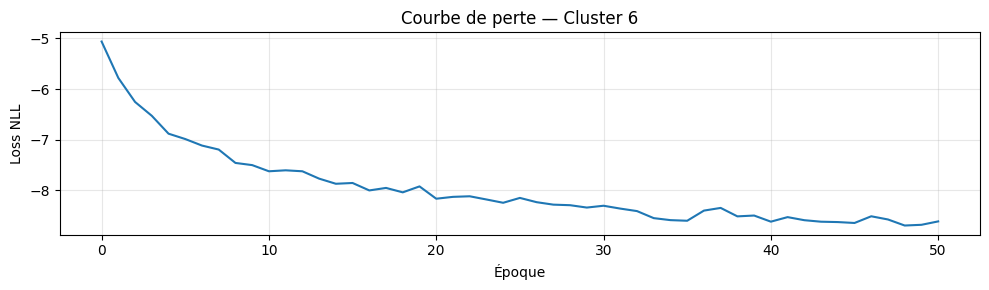

In [13]:
plt.figure(figsize=(10, 3))
plt.plot([x['epoch'] for x in loss_history], [x['loss'] for x in loss_history], lw=1.5)
plt.xlabel('Époque')
plt.ylabel('Loss NLL')
plt.title(f'Courbe de perte — Cluster {CLUSTER_ID}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/loss_curve.png', dpi=150)
plt.show()

## 8 — Inférence

In [14]:
model.eval()
forecasts = []

with torch.no_grad():
    for b in tqdm(test_dataloader, desc='Inférence'):
        out = model.generate(
            static_categorical_features=b['static_categorical_features'].to(device)
                if config.num_static_categorical_features > 0 else None,
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
        )
        forecasts.append(out.sequences.cpu().numpy())

forecasts = np.vstack(forecasts)
print(f'Shape forecasts : {forecasts.shape}  (séries, samples, horizon)')

Inférence: 0it [00:00, ?it/s]

Shape forecasts : (5, 100, 120)  (séries, samples, horizon)


## 9 — Métriques

In [15]:
from evaluate import load as load_metric
from gluonts.time_feature import get_seasonality
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

mase_metric  = load_metric('evaluate-metric/mase')
smape_metric = load_metric('evaluate-metric/smape')
forecast_median = np.median(forecasts, axis=1)

all_metrics = []
for ts_idx in range(len(test_dataset)):
    pred   = forecast_median[ts_idx]
    actual = np.array(test_dataset[ts_idx]['target'][-PREDICTION_LENGTH:])
    train_ = np.array(test_dataset[ts_idx]['target'][:-PREDICTION_LENGTH])

    mase  = mase_metric.compute(predictions=pred, references=actual,
                                 training=train_,
                                 periodicity=get_seasonality(FREQ))['mase']
    smape = smape_metric.compute(predictions=pred, references=actual)['smape']
    rmse  = float(np.sqrt(mean_squared_error(actual, pred)))
    r2    = float(r2_score(actual, pred))
    sp    = float(spearmanr(actual, pred).statistic)

    all_metrics.append({
        'ts_index':    ts_idx,
        'function_id': test_dataset[ts_idx]['function_id'],
        'MASE':  mase, 'sMAPE': smape,
        'RMSE':  rmse, 'R2':    r2, 'Spearman': sp,
    })

df_metrics = pd.DataFrame(all_metrics)
print('── Métriques par fonction ──')
print(df_metrics[['function_id', 'MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']].to_string(index=False))
print('\n── Moyennes ──')
print(df_metrics[['MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']].mean().round(4))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/tmp/ipykernel_3849/1768979487.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp    = float(spearmanr(actual, pred).statistic)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/tmp/ipykernel_3849/1768979487.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp    = float(spearmanr(actual, pred).statistic)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/seasonality.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' ins

── Métriques par fonction ──
 function_id         MASE    sMAPE         RMSE  R2  Spearman
         138 2.875942e-13 1.998666 4.189894e-13 0.0       NaN
         139 2.832861e-13 1.998716 4.119085e-13 0.0       NaN
         140 5.434560e-13 1.998734 4.196872e-13 0.0       NaN
         143 4.962994e-13 1.998704 4.010537e-13 0.0       NaN
         144 1.254117e-13 1.998701 4.300217e-13 0.0       NaN

── Moyennes ──
MASE        0.0000
sMAPE       1.9987
RMSE        0.0000
R2          0.0000
Spearman       NaN
dtype: float64


In [16]:
df_metrics.to_csv(f'{DRIVE_BASE}/results/metrics.csv', index=False)
summary = {
    'run_name': RUN_NAME, 'cluster': CLUSTER_ID, 'seed': SEED, 'num_epochs': NUM_EPOCHS,
    'global': df_metrics[['MASE','sMAPE','RMSE','R2','Spearman']].mean().round(4).to_dict(),
    'per_function': df_metrics.to_dict(orient='records'),
}
with open(f'{DRIVE_BASE}/results/metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Métriques sauvegardées.')

Métriques sauvegardées.


## 10 — Prévisions par fonction

Un graphique par fonction du Cluster 6.  
Chaque graphique montre **6 heures de contexte passé** (360 min) + **2 heures de prévision** (120 min).

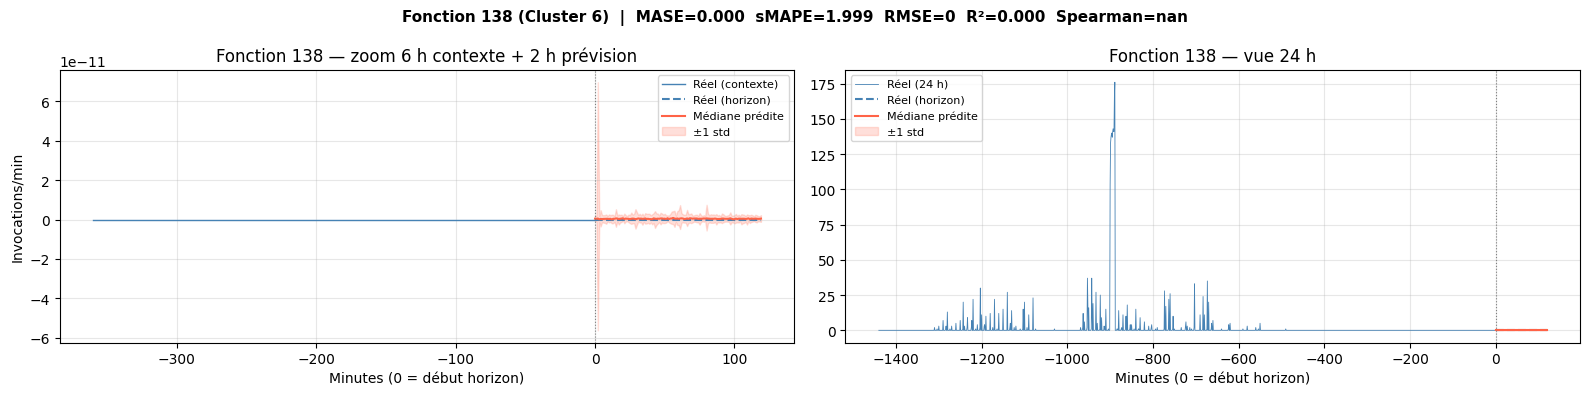

  → function_138 sauvegardée.


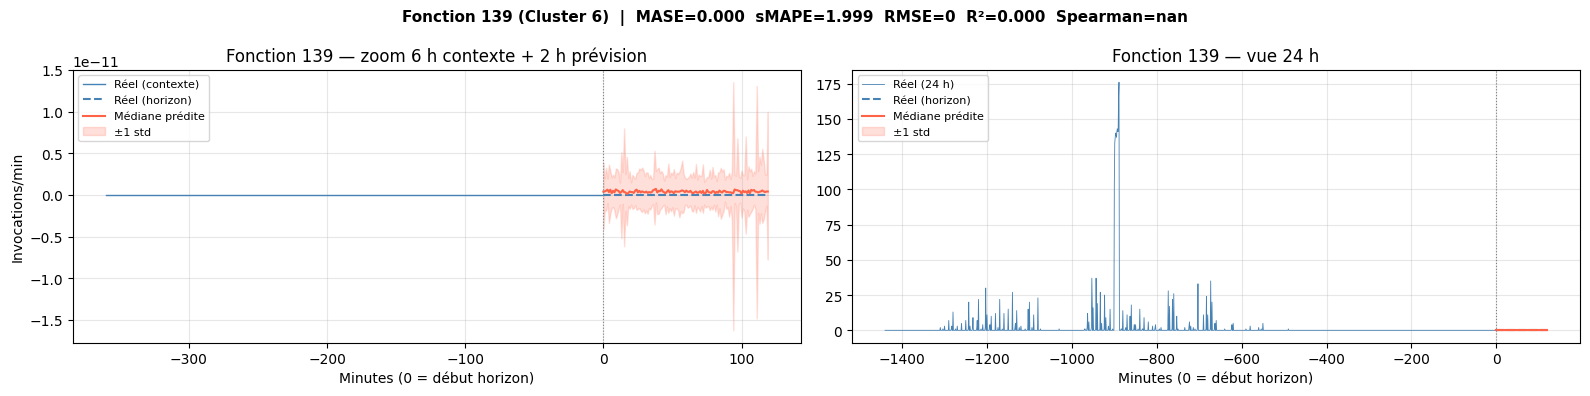

  → function_139 sauvegardée.


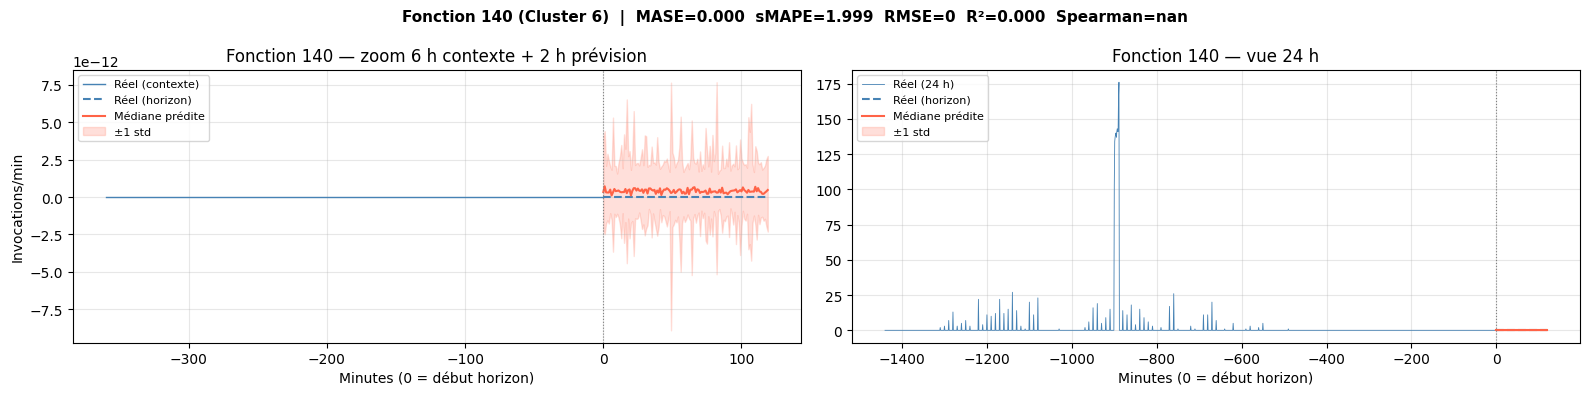

  → function_140 sauvegardée.


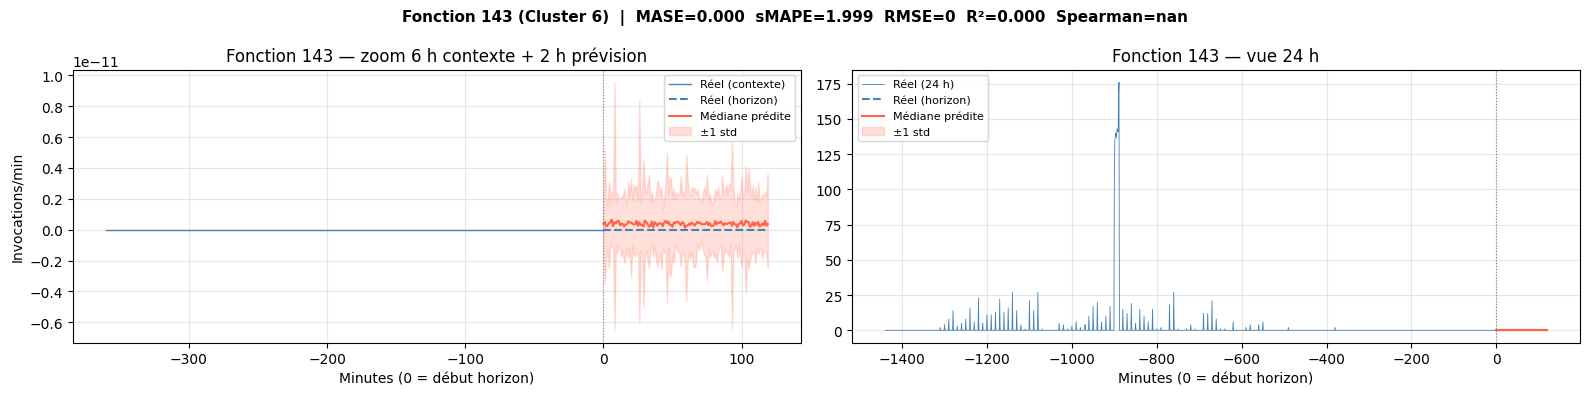

  → function_143 sauvegardée.


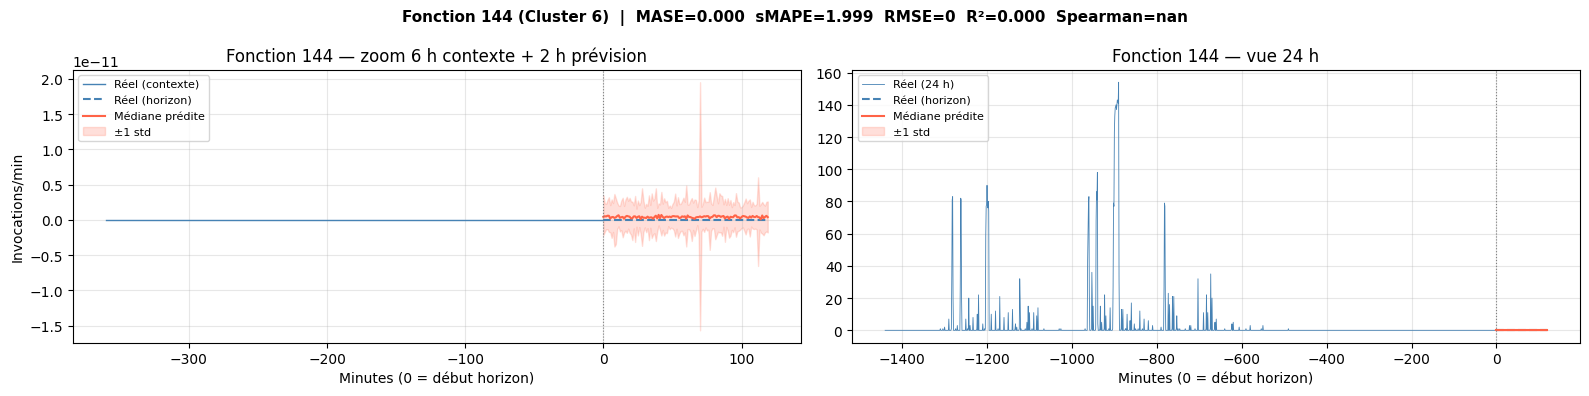

  → function_144 sauvegardée.


In [17]:
CONTEXT_DISPLAY = 360  # 6 heures de contexte visible (3 × prediction_length)

for ts_idx, s in enumerate(all_series):
    func_id = s['function_id']
    row     = df_metrics[df_metrics['ts_index'] == ts_idx].iloc[0]

    actual  = np.array(test_dataset[ts_idx]['target'])
    pred_m  = forecast_median[ts_idx]            # médiane sur 100 samples
    pred_lo = forecasts[ts_idx].mean(0) - forecasts[ts_idx].std(0)
    pred_hi = forecasts[ts_idx].mean(0) + forecasts[ts_idx].std(0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # ── Zoom : contexte 6 h + prévision 2 h ──────────────────────────────────
    ax = axes[0]
    n_ctx = CONTEXT_DISPLAY
    x_ctx  = np.arange(-n_ctx, 0)
    x_pred = np.arange(0, PREDICTION_LENGTH)
    ax.plot(x_ctx,  actual[-(n_ctx + PREDICTION_LENGTH):-PREDICTION_LENGTH],
            color='steelblue', lw=1, label='Réel (contexte)')
    ax.plot(x_pred, actual[-PREDICTION_LENGTH:],
            color='steelblue', lw=1.5, linestyle='--', label='Réel (horizon)')
    ax.plot(x_pred, pred_m,  color='tomato', lw=1.5, label='Médiane prédite')
    ax.fill_between(x_pred, pred_lo, pred_hi, color='tomato', alpha=0.2, label='±1 std')
    ax.axvline(0, color='gray', lw=0.8, linestyle=':')
    ax.set_xlabel('Minutes (0 = début horizon)')
    ax.set_ylabel('Invocations/min')
    ax.set_title(f'Fonction {func_id} — zoom 6 h contexte + 2 h prévision')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Vue 24 h : journée complète + prévision ───────────────────────────────
    ax2 = axes[1]
    n_day = 1440
    x_day  = np.arange(-n_day, 0)
    x_pred2 = np.arange(0, PREDICTION_LENGTH)
    ax2.plot(x_day, actual[-(n_day + PREDICTION_LENGTH):-PREDICTION_LENGTH],
             color='steelblue', lw=0.6, label='Réel (24 h)')
    ax2.plot(x_pred2, actual[-PREDICTION_LENGTH:],
             color='steelblue', lw=1.5, linestyle='--', label='Réel (horizon)')
    ax2.plot(x_pred2, pred_m, color='tomato', lw=1.5, label='Médiane prédite')
    ax2.fill_between(x_pred2, pred_lo, pred_hi, color='tomato', alpha=0.2, label='±1 std')
    ax2.axvline(0, color='gray', lw=0.8, linestyle=':')
    ax2.set_xlabel('Minutes (0 = début horizon)')
    ax2.set_title(f'Fonction {func_id} — vue 24 h')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    fig.suptitle(
        f'Fonction {func_id} (Cluster {CLUSTER_ID})  |  '
        f'MASE={row.MASE:.3f}  sMAPE={row.sMAPE:.3f}  '
        f'RMSE={row.RMSE:.0f}  R²={row.R2:.3f}  Spearman={row.Spearman:.3f}',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{DRIVE_BASE}/results/forecast_function_{func_id}.png', dpi=150)
    plt.show()
    print(f'  → function_{func_id} sauvegardée.')

## 11 — Vue comparative : les 5 fonctions côte à côte

Superposition normalisée des 3 fonctions pour comparer les profils de prévision.

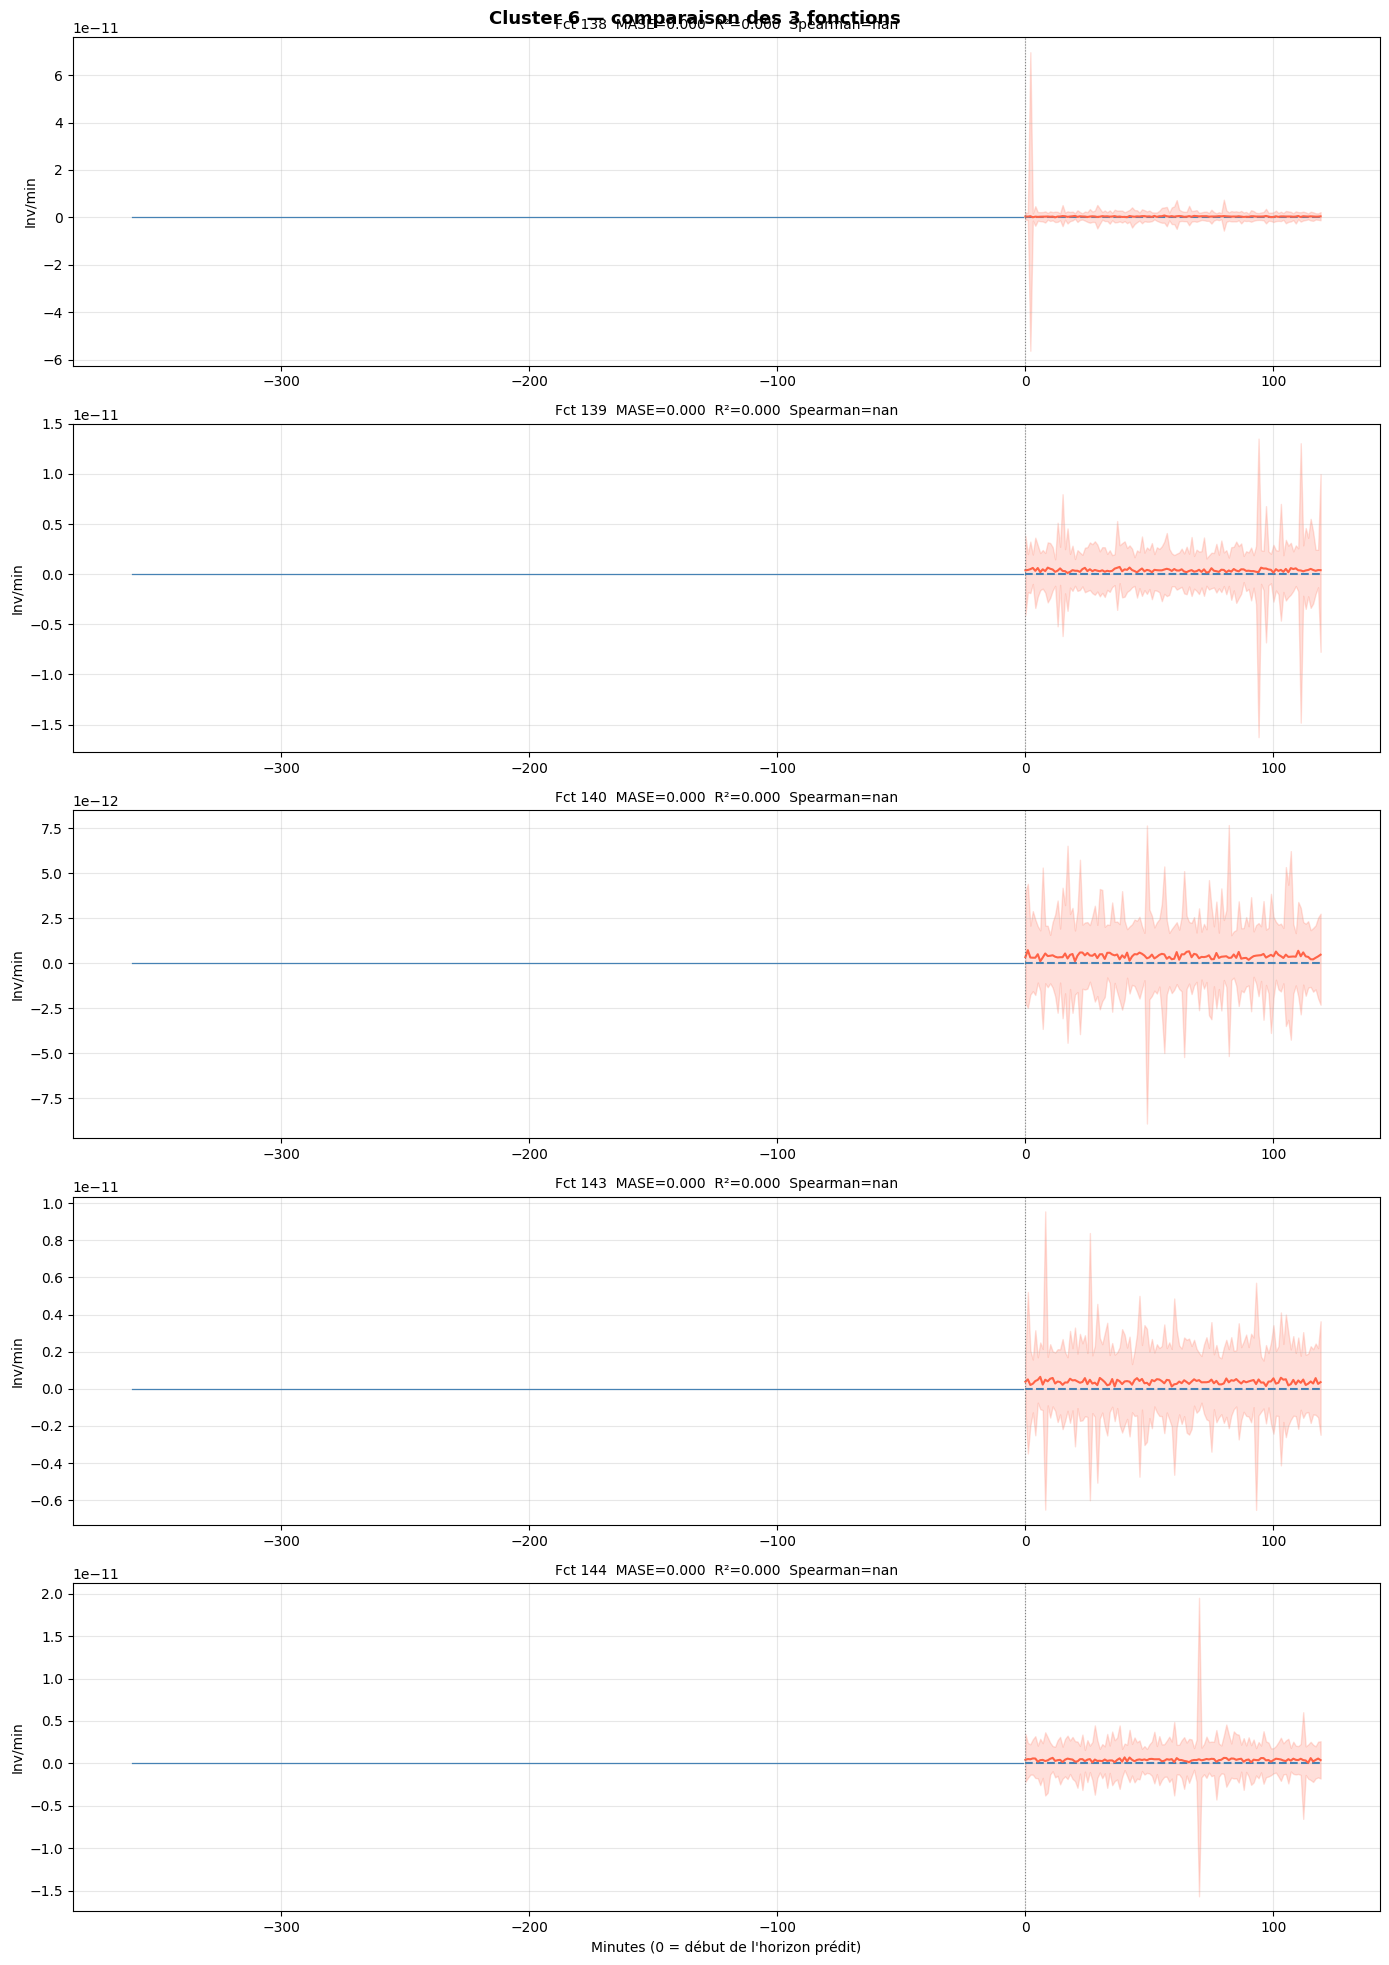

In [18]:
fig, axes = plt.subplots(len(all_series), 1, figsize=(14, 4 * len(all_series)), squeeze=False)

for ts_idx, (s, ax) in enumerate(zip(all_series, axes.flatten())):
    func_id = s['function_id']
    row     = df_metrics[df_metrics['ts_index'] == ts_idx].iloc[0]
    actual  = np.array(test_dataset[ts_idx]['target'])
    pred_m  = forecast_median[ts_idx]
    pred_lo = forecasts[ts_idx].mean(0) - forecasts[ts_idx].std(0)
    pred_hi = forecasts[ts_idx].mean(0) + forecasts[ts_idx].std(0)

    n_ctx  = CONTEXT_DISPLAY
    x_ctx  = np.arange(-n_ctx, 0)
    x_pred = np.arange(0, PREDICTION_LENGTH)

    ax.plot(x_ctx,  actual[-(n_ctx + PREDICTION_LENGTH):-PREDICTION_LENGTH],
            color='steelblue', lw=0.9)
    ax.plot(x_pred, actual[-PREDICTION_LENGTH:],
            color='steelblue', lw=1.5, linestyle='--')
    ax.plot(x_pred, pred_m,  color='tomato', lw=1.5)
    ax.fill_between(x_pred, pred_lo, pred_hi, color='tomato', alpha=0.2)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':')
    ax.set_ylabel('Inv/min')
    ax.set_title(
        f'Fct {func_id}  MASE={row.MASE:.3f}  R²={row.R2:.3f}  Spearman={row.Spearman:.3f}',
        fontsize=10
    )
    ax.grid(alpha=0.3)

axes[-1][0].set_xlabel('Minutes (0 = début de l\'horizon prédit)')
fig.suptitle(f'Cluster {CLUSTER_ID} — comparaison des 3 fonctions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/results/forecast_cluster{CLUSTER_ID}_comparison.png', dpi=150)
plt.show()

## 12 — Extraction attention (`output_attentions=True`)

Forward pass teacher-forcé sur les 5 séries. Sauvegarde `.npy` sur Drive.

In [19]:
attn_loader = create_attention_dataloader(
    config=config, freq=FREQ, data=test_dataset, batch_size=1)

model.eval()
cross_attn_list, enc_attn_list = [], []

with torch.no_grad():
    for i, batch in enumerate(tqdm(attn_loader, total=len(all_series),
                                   desc='Extraction attention')):
        if i >= len(all_series):
            break
        out = model(
            past_values=batch['past_values'].to(device),
            past_time_features=batch['past_time_features'].to(device),
            past_observed_mask=batch['past_observed_mask'].to(device),
            future_values=batch['future_values'].to(device),
            future_time_features=batch['future_time_features'].to(device),
            future_observed_mask=batch['future_observed_mask'].to(device),
            static_categorical_features=batch['static_categorical_features'].to(device)
                if config.num_static_categorical_features > 0 else None,
            output_attentions=True,
        )
        cross_attn_list.append(out.cross_attentions[-1].squeeze(0).cpu().numpy())
        enc_attn_list.append(out.encoder_attentions[-1].squeeze(0).cpu().numpy())

cross_attn_arr = np.stack(cross_attn_list)  # (3, heads, pred_len, ctx_len)
enc_attn_arr   = np.stack(enc_attn_list)

np.save(f'{DRIVE_BASE}/attentions/cross_attentions_last_layer.npy', cross_attn_arr)
np.save(f'{DRIVE_BASE}/attentions/encoder_attentions_last_layer.npy', enc_attn_arr)
print(f'cross_attn_arr : {cross_attn_arr.shape}')
print(f'enc_attn_arr   : {enc_attn_arr.shape}')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


Extraction attention:   0%|          | 0/5 [00:00<?, ?it/s]

cross_attn_arr : (5, 2, 120, 240)
enc_attn_arr   : (5, 2, 240, 240)


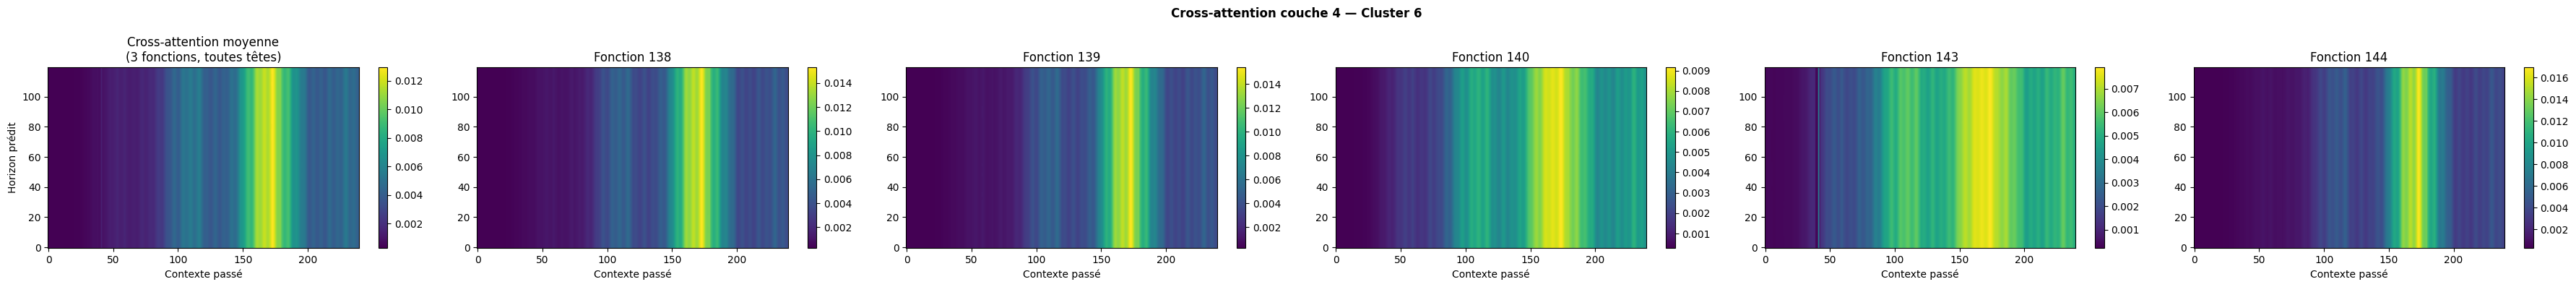

In [20]:
# Heatmap cross-attention moyenne + par fonction
fig, axes = plt.subplots(1, len(all_series) + 1, figsize=(6 * (len(all_series) + 1), 4))

# Moyenne sur les 3 fonctions
mean_cross = cross_attn_arr.mean(axis=(0, 1))  # (pred_len, ctx_len)
im = axes[0].imshow(mean_cross, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Cross-attention moyenne\n(3 fonctions, toutes têtes)')
axes[0].set_xlabel('Contexte passé')
axes[0].set_ylabel('Horizon prédit')

# Par fonction
for ts_idx, s in enumerate(all_series):
    mc = cross_attn_arr[ts_idx].mean(axis=0)  # moyenne sur les têtes
    im2 = axes[ts_idx + 1].imshow(mc, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(im2, ax=axes[ts_idx + 1])
    axes[ts_idx + 1].set_title(f'Fonction {s["function_id"]}')
    axes[ts_idx + 1].set_xlabel('Contexte passé')

plt.suptitle(f'Cross-attention couche {DECODER_LAYERS} — Cluster {CLUSTER_ID}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/attentions/cross_attention_heatmap.png', dpi=150)
plt.show()

## 13 — Sauvegarde finale

In [21]:
torch.save(model.state_dict(), f'{DRIVE_BASE}/checkpoints/model_final.pt')

print('=' * 60)
print(f'Run complet — Cluster {CLUSTER_ID}')
print(f'Artefacts : {DRIVE_BASE}')
print('=' * 60)
print('\n── Résumé final ──')
print(df_metrics[['function_id', 'MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']].to_string(index=False))
print('\nMoyenne :')
print(df_metrics[['MASE', 'sMAPE', 'RMSE', 'R2', 'Spearman']].mean().round(4))

Run complet — Cluster 6
Artefacts : /content/drive/MyDrive/m2-xai-faas/experiments/baseline-cluster6

── Résumé final ──
 function_id         MASE    sMAPE         RMSE  R2  Spearman
         138 2.875942e-13 1.998666 4.189894e-13 0.0       NaN
         139 2.832861e-13 1.998716 4.119085e-13 0.0       NaN
         140 5.434560e-13 1.998734 4.196872e-13 0.0       NaN
         143 4.962994e-13 1.998704 4.010537e-13 0.0       NaN
         144 1.254117e-13 1.998701 4.300217e-13 0.0       NaN

Moyenne :
MASE        0.0000
sMAPE       1.9987
RMSE        0.0000
R2          0.0000
Spearman       NaN
dtype: float64
